# Distributions and combinators

The pillars of statistical modeling are (a) data, (b) distributions, and (c) statistics. This notebook is the parts catalog for mixle: it shows how a model is represented, how data are sampled, and how estimators recover parameters from data.

mixle has four main object types:

* Distributions evaluate probability, density, and log-density for an observation.
* Samplers draw synthetic observations from a distribution.
* Accumulators collect sufficient statistics from observations.
* Estimators map sufficient statistics back to fitted distributions.

The examples use synthetic data because the goal here is not a scientific claim; it is calibration. Each section follows the same test: generate data from a known distribution, estimate the model, and compare the fitted density to the generating density. The later notebooks use the same building blocks on real text, translation, and certificate data.

References and useful background: the mixle repository (https://github.com/gmboquet/mixle); the exponential-family view of sufficient statistics in standard statistical modeling; and the notebook-specific references in the real-data examples linked from the README.


In [1]:
import numpy as np
import io
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


%matplotlib inline
from mixle.inference.estimation import optimize

In [2]:
from mixle.stats import AffineTransform, BernoulliDistribution, BernoulliSetDistribution, BernoulliSetEstimator, BetaDistribution, BinomialDistribution, CategoricalDistribution, CategoricalEstimator, CompositeDistribution, CompositeEstimator, ConditionalDistribution, ConditionalDistributionEstimator, DirichletDistribution, DirichletEstimator, ExponentialDistribution, ExponentialEstimator, GammaDistribution, GammaEstimator, GaussianDistribution, GaussianEstimator, GeometricDistribution, GeometricEstimator, IgnoredDistribution, IgnoredEstimator, IntegerCategoricalDistribution, IntegerMultinomialDistribution, IntegerMultinomialEstimator, IntegerUniformSpikeDistribution, LaplaceDistribution, LogGaussianDistribution, LogisticDistribution, MarkovChainDistribution, MarkovChainEstimator, MultivariateGaussianDistribution, MultivariateGaussianEstimator, NegativeBinomialDistribution, OptionalDistribution, OptionalEstimator, ParetoDistribution, PoissonDistribution, PoissonEstimator, RayleighDistribution, RecordDistribution, SelectDistribution, certify_select_routing, SequenceDistribution, SequenceEstimator, SpearmanRankingDistribution, StudentTDistribution, TransformDistribution, UniformDistribution, VonMisesFisherDistribution, VonMisesFisherEstimator, WeibullDistribution, WeightedDistribution
from mixle.inference import estimate

## Base distributions
## Continuous distributions


### Gaussian distribution


$\ell(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$


In [3]:
omodel = GaussianDistribution(mu=2.0, sigma2=6.4)
data = omodel.sampler(seed=1).sample(1000)
emodel = estimate(data, GaussianEstimator())
print(emodel)

GaussianDistribution(2.0981886610362643, 6.1591623090694, name=None, keys=None)


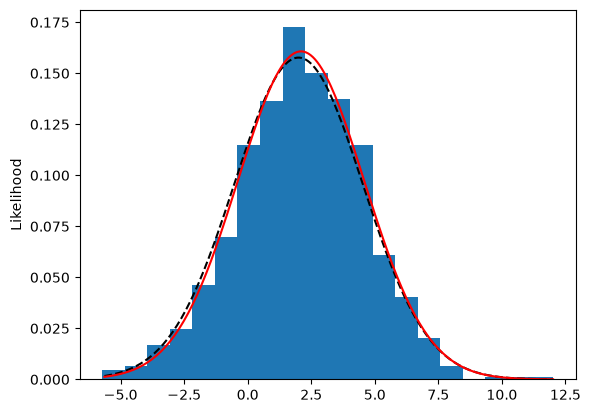

In [4]:
fig, ax = plt.subplots()

omodel = GaussianDistribution(mu=2.0, sigma2=6.4)
data = omodel.sampler(seed=1).sample(1000)
emodel = estimate(data, GaussianEstimator())

xvals = np.linspace(np.min(data), np.max(data), 200)[1:]

ax.hist(data, bins=20, density=True)
ax.plot(xvals, [omodel.density(u) for u in xvals], '--k', label='Real Model')
ax.plot(xvals, [emodel.density(u) for u in xvals], 'r', label='Estimated Model')
ax.set_ylabel('Likelihood');

### Gamma distribution


$\ell(x|k, \theta) = \frac{x^{k-1} e^{-x/\theta}}{\Gamma(k)\theta^k}$


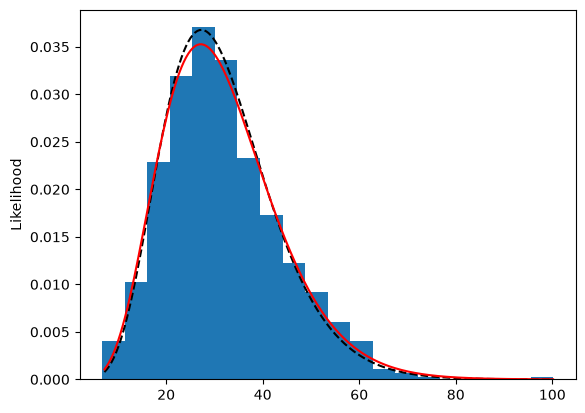

In [5]:
fig, ax = plt.subplots()

omodel = GammaDistribution(k=7.5, theta=4.2)
data = omodel.sampler(seed=1).sample(1000)
emodel = estimate(data, GammaEstimator())

xvals = np.linspace(np.min(data), np.max(data), 200)[1:]

ax.hist(data, bins=20, density=True)
ax.plot(xvals, [omodel.density(u) for u in xvals], '--k', label='Real Model')
ax.plot(xvals, [emodel.density(u) for u in xvals], 'r', label='Estimated Model')
ax.set_ylabel('Likelihood');

### Exponential distribution


$\ell(x | \beta) = \frac{1}{\beta}e^{-x/\beta}$


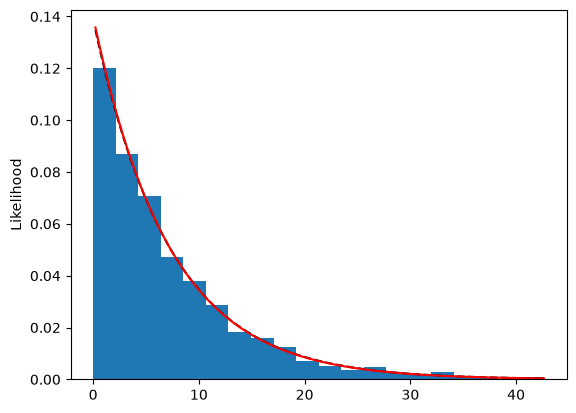

In [6]:
fig, ax = plt.subplots()

omodel = ExponentialDistribution(beta=7.2)
data = omodel.sampler(seed=1).sample(1000)
emodel = estimate(data, ExponentialEstimator())

xvals = np.linspace(np.min(data), np.max(data), 200)[1:]

ax.hist(data, bins=20, density=True)
ax.plot(xvals, [omodel.density(u) for u in xvals], '--k', label='Real Model')
ax.plot(xvals, [emodel.density(u) for u in xvals], 'r', label='Estimated Model')
ax.set_ylabel('Likelihood');

### Dirichlet distribution


$\ell(x_1, \ldots, x_n | \alpha_1, \ldots, \alpha_n) = \frac{\Gamma\left(\sum_{i=1}^n \alpha_i\right)}{\prod_{i=1}^n \Gamma(\alpha_i)}\prod_{i = 1}^n x^{\alpha_i - 1}, \sum_{i=1}^n x_i = 1, a_i, x_i > 0$ for all $i = 1, \ldots, n$.


DirichletDistribution([np.float64(0.07788527231424283), np.float64(0.059228594274873245), np.float64(0.09167522063651973)], name=None, keys=None)


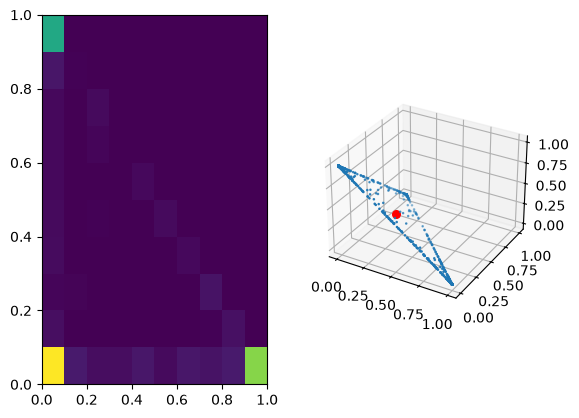

In [7]:
fig = plt.figure()
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')


data = DirichletDistribution(alpha=[0.08, 0.06, 0.09]).sampler(seed=1).sample(1000)
ax1.hist2d(data[:,0], data[:,1], bins=10, )
ax2.scatter(data[:,0], data[:,1], data[:,2], s=0.7)
ax2.scatter(np.mean(data[:,0]), np.mean(data[:,1]), np.mean(data[:,2]), c='r', s=30)
print(str(estimate(data, DirichletEstimator(3))))

### Multivariate normal


MultivariateGaussianDistribution([np.float64(1.93278577435275), np.float64(1.9704548869025498)], [[np.float64(1.9625210391955161), np.float64(1.021911775907028)], [np.float64(1.021911775907028), np.float64(2.094388933402002)]], name=None, keys=None)


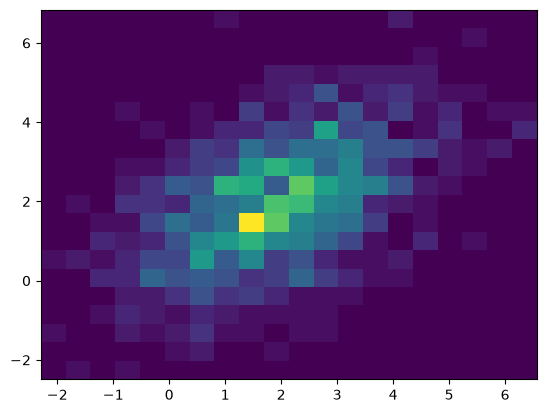

In [8]:
fig = plt.figure()
ax  = fig.add_subplot(111)

dist = MultivariateGaussianDistribution([2,2], [[2,1],[1,2]])
data = dist.sampler(seed=1).sample(1000)

data = np.asarray(data)
ax.hist2d(data[:, 0], data[:, 1], bins=20)

print(str(estimate(data, MultivariateGaussianEstimator(dim=2))))

### Von Mises-Fisher distribution


VonMisesFisherDistribution([0.7014634300222867, 0.7127054485138783], 3.126966439229296, name=None, keys=None)


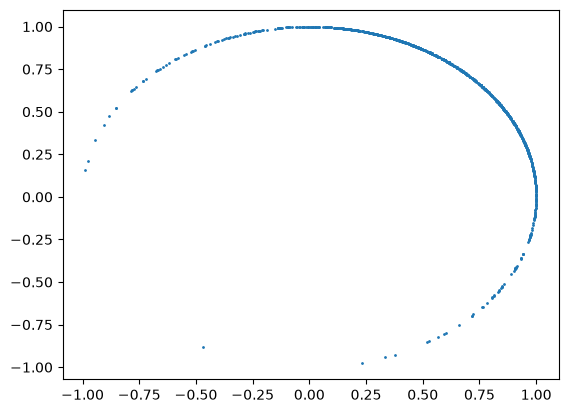

In [9]:
fig = plt.figure()
ax  = fig.add_subplot(111)

data = VonMisesFisherDistribution(np.ones(2)/np.sqrt(2), 3.0).sampler(seed=1).sample(1000)
print(str(estimate(data, VonMisesFisherEstimator(2))))
ax.scatter(data[:,0], data[:,1], s=1);

VonMisesFisherDistribution([0.5932143356719213, 0.5727654619813995, 0.565717665902838], 4.116930680102554, name=None, keys=None)


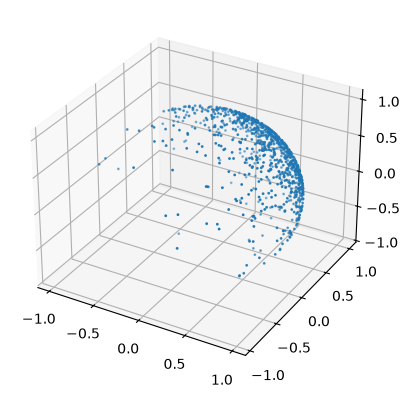

In [10]:
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

data = VonMisesFisherDistribution(np.ones(3)/np.sqrt(3), 4.0).sampler(seed=1).sample(1000)
print(str(estimate(data, VonMisesFisherEstimator(3))))
ax.scatter(data[:,0], data[:,1], data[:,2], s=1);

## Discrete distributions


### Geometric distribution
$P(k|p) = (1-p)^{k-1} p, \qquad k \in \mathbb{N}$


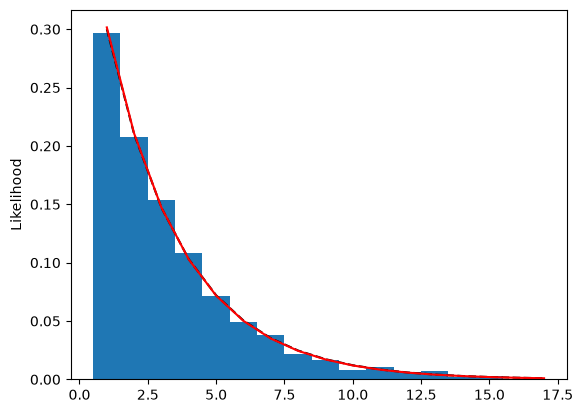

In [11]:
fig, ax = plt.subplots()

omodel = GeometricDistribution(0.3)
data = omodel.sampler(seed=1).sample(1000)
emodel = estimate(data, GeometricEstimator())

xvals = np.arange(np.min(data), np.max(data)+1)

ax.hist(data, bins=xvals-0.5, density=True)
ax.plot(xvals, [omodel.density(u) for u in xvals], '--k', label='Real Model')
ax.plot(xvals, [emodel.density(u) for u in xvals], 'r', label='Estimated Model')
ax.set_ylabel('Likelihood');

### Poisson distribution


$\ell(k|\lambda) = \frac{\lambda^k e^{-\lambda}}{k!}$


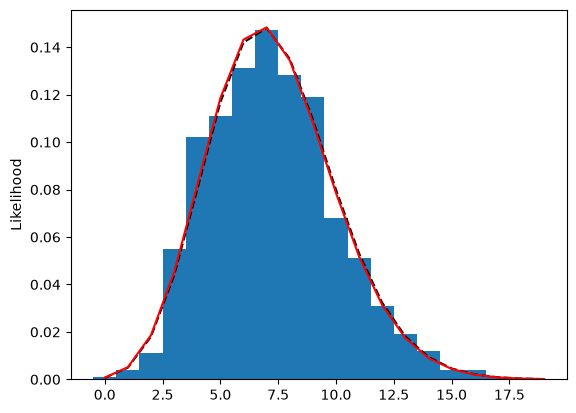

In [12]:
fig, ax = plt.subplots()

omodel = PoissonDistribution(lam=7.3)
data = omodel.sampler(seed=1).sample(1000)
emodel = estimate(data, PoissonEstimator())

xvals = np.arange(np.min(data), np.max(data)+1)

ax.hist(data, bins=xvals-0.5, density=True)
ax.plot(xvals, [omodel.density(u) for u in xvals], '--k', label='Real Model')
ax.plot(xvals, [emodel.density(u) for u in xvals], 'r', label='Estimated Model')
ax.set_ylabel('Likelihood');

### Categorical distribution
This is simply a discrete random variable where the probability of each state specified and the total probability of all given values sums to one.


In [13]:
data = CategoricalDistribution({'cat': 0.1, 'dog': 0.3, 'turtle': 0.6}).sampler(seed=1).sample(1000)
uvals, _, _, cnts = np.unique(np.asarray(data, dtype=object), True, True, True)
print(str(dict(zip(uvals, cnts/sum(cnts)))))
print(str(estimate(data, CategoricalEstimator())))

{'cat': np.float64(0.097), 'dog': np.float64(0.292), 'turtle': np.float64(0.611)}
CategoricalDistribution({'cat': 0.097, 'dog': 0.292, 'turtle': 0.611}, default_value=0.0, name=None, keys=None)


### Bernoulli set distributions


$P({s_1, \ldots, s_N})=\prod_{j = 1}^N (P(s_j)^{s_j} + (1-P(s_j))^{1-s_j})$


In [14]:
data = BernoulliSetDistribution({'cat': 0.9, 'dog': 0.3, 'turtle': 0.6}).sampler(seed=1).sample(1000)
print('Sample data:')
print('\n'.join([str(data[i]) for i in range(10)]))
print('\nEstimate:')
print(str(estimate(data, BernoulliSetEstimator())))

Sample data:
['cat', 'turtle']
['cat']
['cat']
['cat', 'turtle']
['cat', 'turtle']
['cat', 'dog', 'turtle']
['cat', 'dog']
['cat', 'turtle']
['cat', 'dog', 'turtle']
['cat', 'turtle']

Estimate:
BernoulliSetDistribution(dict([('cat', 0.898), ('turtle', 0.63), ('dog', 0.292)]), min_prob=1e-128, name=None, keys=None)


### Markov chains


In [15]:
init_prob = {'a': 0.4, 'b': 0.4, 'c':0.2}
trans_map = {'a': {'a': 0.8, 'b': 0.2}, 'b': {'b': 0.8, 'c': 0.2}, 'c': {'a': 0.5, 'b': 0.5}}
len_dist = CategoricalDistribution({3:0.5, 8:0.5})
dist = MarkovChainDistribution(init_prob, trans_map, len_dist=len_dist)

data = dist.sampler(seed=1).sample(1000)
print('Estimate:')
print(str(estimate(data, MarkovChainEstimator(len_estimator=CategoricalEstimator()))))
print('Samples:')
print('\n'.join(map(str, data[:5])))

Estimate:
MarkovChainDistribution({'a': 0.418, 'b': 0.391, 'c': 0.191}, {'a': {'a': 0.8004600345025877, 'b': 0.19953996549741232, 'c': 0.0}, 'b': {'a': 0.0, 'b': 0.79140832595217, 'c': 0.20859167404782994}, 'c': {'a': 0.4799301919720768, 'b': 0.5200698080279232, 'c': 0.0}}, len_dist=CategoricalDistribution({3: 0.486, 8: 0.514}, default_value=0.0, name=None, keys=None), default_value=0.0, name=None)
Samples:
['c', 'a', 'a']
['c', 'a', 'a', 'a', 'a', 'a', 'a', 'b']
['a', 'a', 'a', 'b', 'b', 'c', 'b', 'b']
['c', 'a', 'a']
['a', 'a', 'a', 'a', 'a', 'a', 'b', 'c']


## The complete leaf catalog

The sections above introduce a representative handful in detail. Every leaf distribution in `mixle.stats` follows the identical protocol - construct it, draw samples with `.sampler(seed).sample(n)`, score with `.log_density(x)` - so the whole catalog fits in two figures. Below, each univariate family is drawn as a sample histogram (blue) with its analytic density or PMF overlaid (red); the overlay landing on the bars is a visual check that sampling and scoring agree.


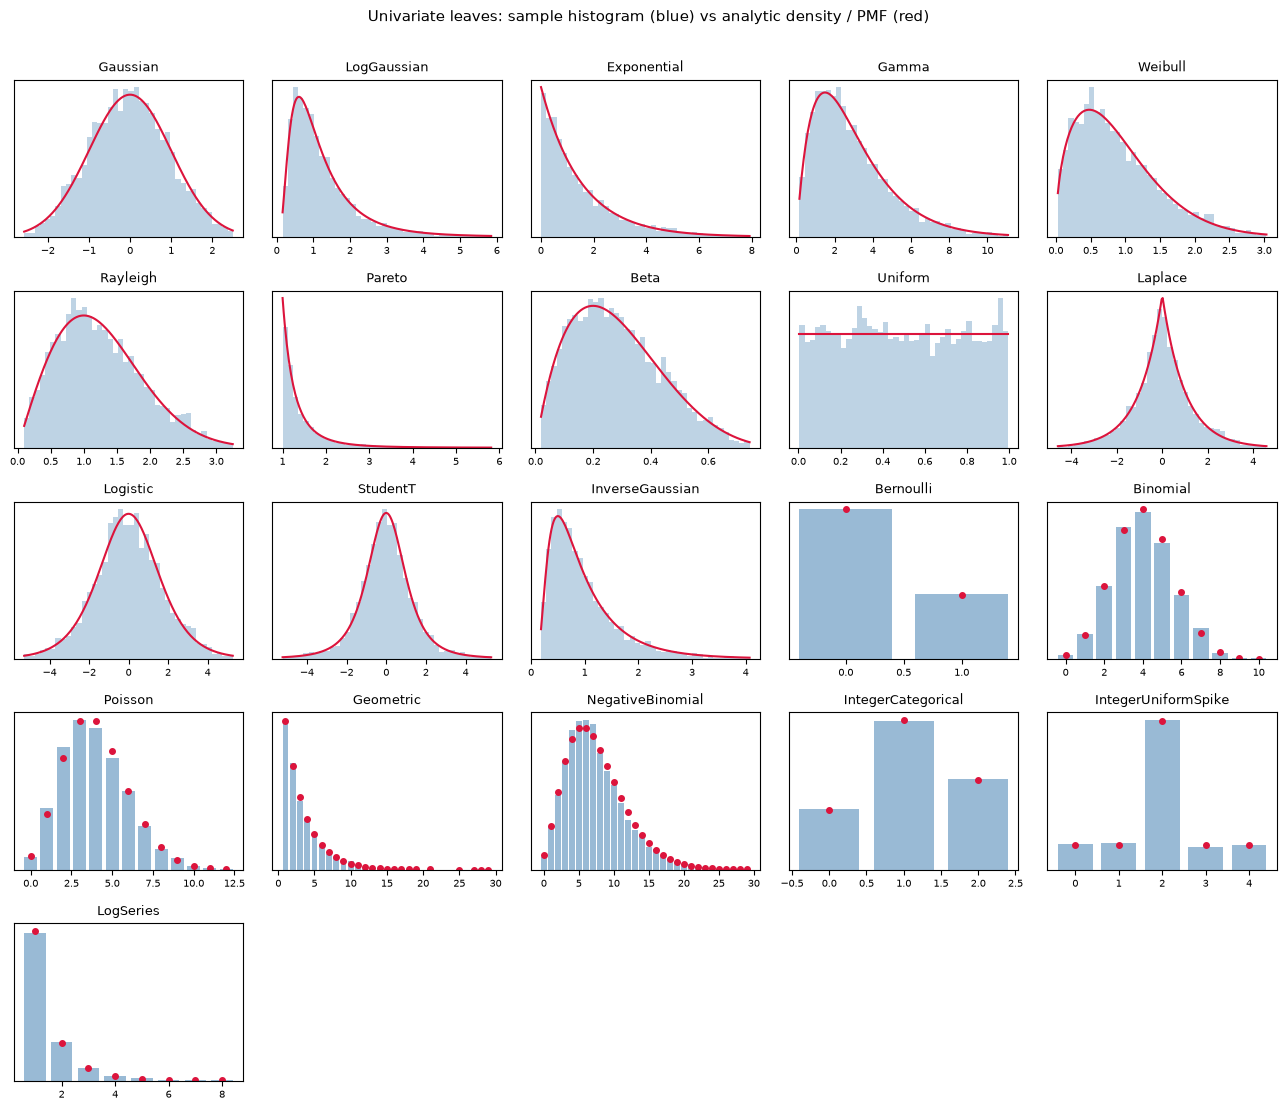

In [16]:
import matplotlib.pyplot as plt
from mixle.stats import InverseGaussianDistribution, LogSeriesDistribution

leaves_cont = [
    ('Gaussian',     GaussianDistribution(0.0, 1.0)),  ('LogGaussian', LogGaussianDistribution(0.0, 0.5)),
    ('Exponential',  ExponentialDistribution(1.5)),    ('Gamma',       GammaDistribution(2.0, 1.5)),
    ('Weibull',      WeibullDistribution(1.5, 1.0)),   ('Rayleigh',    RayleighDistribution(1.0)),
    ('Pareto',       ParetoDistribution(1.0, 3.0)),    ('Beta',        BetaDistribution(2.0, 5.0)),
    ('Uniform',      UniformDistribution(0.0, 1.0)),   ('Laplace',     LaplaceDistribution(0.0, 1.0)),
    ('Logistic',     LogisticDistribution(0.0, 1.0)),  ('StudentT',    StudentTDistribution(3.0, 0.0, 1.0)),
    ('InverseGaussian', InverseGaussianDistribution(1.0, 2.0)),
]
leaves_disc = [
    ('Bernoulli',        BernoulliDistribution(0.3)),          ('Binomial',  BinomialDistribution(0.4, 10)),
    ('Poisson',          PoissonDistribution(4.0)),            ('Geometric', GeometricDistribution(0.3)),
    ('NegativeBinomial', NegativeBinomialDistribution(5.0, 0.4)),
    ('IntegerCategorical', IntegerCategoricalDistribution(0, [0.2, 0.5, 0.3])),
    ('IntegerUniformSpike', IntegerUniformSpikeDistribution(2, 5, 0.6)),
    ('LogSeries', LogSeriesDistribution(0.5)),
]

def _panel_cont(ax, name, d):
    s = np.array(d.sampler(seed=0).sample(4000), dtype=float)
    lo, hi = np.percentile(s, 0.5), np.percentile(s, 99.5)
    xs = np.linspace(lo, hi, 200)
    ax.hist(s, bins=40, range=(lo, hi), density=True, alpha=0.35, color='steelblue')
    ax.plot(xs, np.exp([d.log_density(float(x)) for x in xs]), color='crimson', lw=1.5)
    ax.set_title(name, fontsize=9); ax.set_yticks([]); ax.tick_params(labelsize=7)

def _panel_disc(ax, name, d):
    s = np.array(d.sampler(seed=0).sample(4000))
    if s.dtype == bool: s = s.astype(int)
    vals, counts = np.unique(s, return_counts=True)
    ax.bar(vals, counts / len(s), color='steelblue', alpha=0.55, width=0.8)
    ax.plot(vals, np.exp([d.log_density(int(v)) for v in vals]), 'o', color='crimson', ms=4)
    ax.set_title(name, fontsize=9); ax.set_yticks([]); ax.tick_params(labelsize=7)

fig, axes = plt.subplots(5, 5, figsize=(13, 11)); axes = axes.ravel()
panels = [(_panel_cont, n, d) for n, d in leaves_cont] + [(_panel_disc, n, d) for n, d in leaves_disc]
for ax, (fn, n, d) in zip(axes, panels):
    fn(ax, n, d)
for ax in axes[len(panels):]:
    ax.axis('off')
fig.suptitle('Univariate leaves: sample histogram (blue) vs analytic density / PMF (red)', y=1.005, fontsize=11)
fig.tight_layout(); plt.show()

The remaining leaves live on structured supports - vectors, the simplex, the sphere, sets, permutations - so each gets a viz suited to its space:


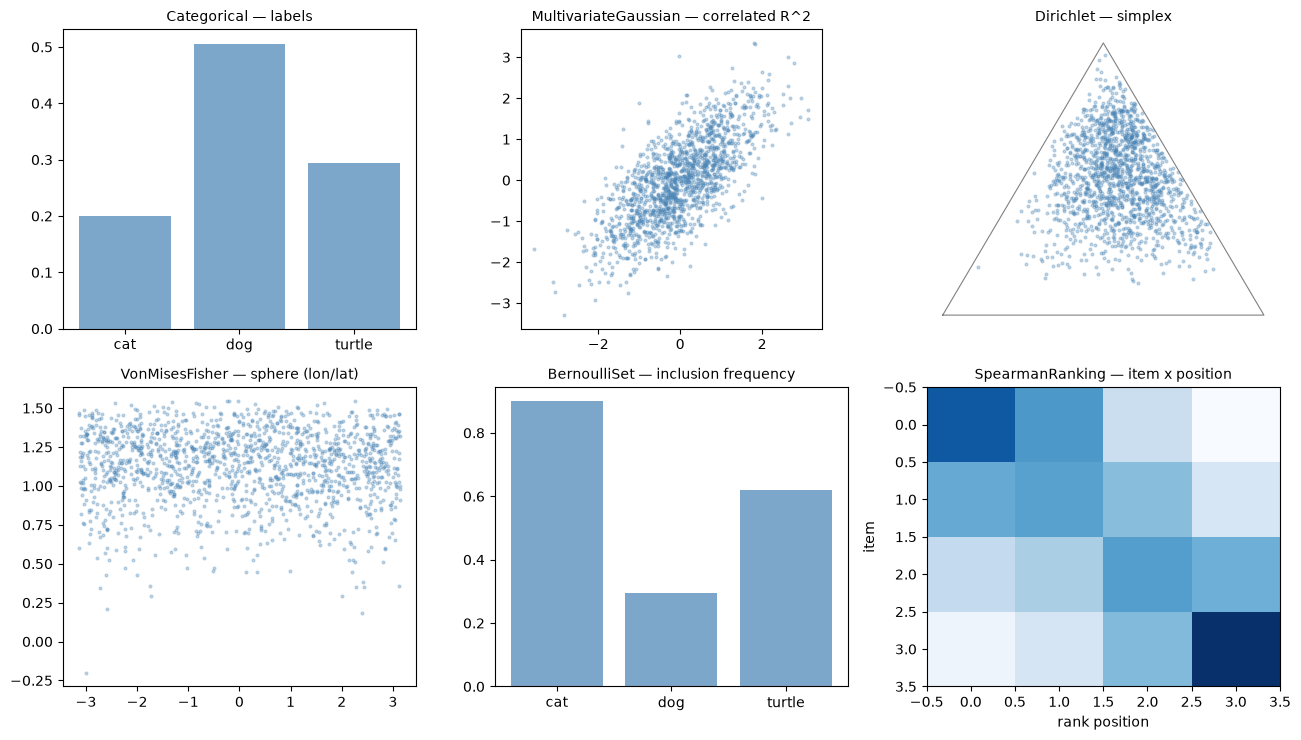

In [17]:
from collections import Counter

fig, ax = plt.subplots(2, 3, figsize=(13, 7.5)); ax = ax.ravel()

# Categorical — probabilities over labels
c = CategoricalDistribution({'cat': 0.2, 'dog': 0.5, 'turtle': 0.3})
v, n = np.unique(c.sampler(seed=1).sample(3000), return_counts=True)
ax[0].bar(v, n / 3000, color='steelblue', alpha=0.7); ax[0].set_title('Categorical — labels', fontsize=10)

# MultivariateGaussian — correlated R^2 cloud
pts = np.array(MultivariateGaussianDistribution([0, 0], [[1, 0.7], [0.7, 1]]).sampler(seed=1).sample(1500))
ax[1].scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.3, color='steelblue')
ax[1].set_title('MultivariateGaussian — correlated R^2', fontsize=10); ax[1].set_aspect('equal')

# Dirichlet — points on the 2-simplex
D = np.array(DirichletDistribution([2.0, 3.0, 5.0]).sampler(seed=1).sample(1500))
corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2]]); XY = D @ corners
ax[2].scatter(XY[:, 0], XY[:, 1], s=4, alpha=0.3, color='steelblue')
ax[2].plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color='gray', lw=0.8)
ax[2].set_title('Dirichlet — simplex', fontsize=10); ax[2].axis('off')

# VonMisesFisher — directions on the sphere (lon/lat)
V = np.array(VonMisesFisherDistribution([0, 0, 1.0], 8.0).sampler(seed=1).sample(1500))
ax[3].scatter(np.arctan2(V[:, 1], V[:, 0]), np.arcsin(np.clip(V[:, 2], -1, 1)), s=4, alpha=0.3, color='steelblue')
ax[3].set_title('VonMisesFisher — sphere (lon/lat)', fontsize=10)

# BernoulliSet — per-element inclusion frequency
sets = BernoulliSetDistribution({'cat': 0.9, 'dog': 0.3, 'turtle': 0.6}).sampler(seed=1).sample(3000)
cnt = Counter(x for st in sets for x in st); keys = ['cat', 'dog', 'turtle']
ax[4].bar(keys, [cnt[k] / 3000 for k in keys], color='steelblue', alpha=0.7)
ax[4].set_title('BernoulliSet — inclusion frequency', fontsize=10)

# SpearmanRanking — how often each item lands in each rank position
R = np.array(SpearmanRankingDistribution([0.05, 0.15, 0.3, 0.5]).sampler(seed=1).sample(3000))
m = R.shape[1]; H = np.zeros((m, m))
for r in R:
    for item, pos in enumerate(r): H[item, pos] += 1
ax[5].imshow(H / 3000, cmap='Blues', aspect='auto')
ax[5].set_title('SpearmanRanking — item x position', fontsize=10)
ax[5].set_xlabel('rank position'); ax[5].set_ylabel('item')

fig.tight_layout(); plt.show()

`Multinomial` / `IntegerMultinomial` (counts over categories) and `IntegerMarkovChain` round out the discrete families; they take an inner distribution and so read as small combinators. Anything latent - `Mixture`, `HiddenMarkovModel`, `LDA`, `ChowLiuTree`, the graph and PCFG families - is built the same way but introduced in latent_variable_models.


### Multinomial - counts over a fixed vocabulary

`IntegerMultinomial` (and `Multinomial`) model a vector of counts over `K` categories - a bag of draws from a categorical, the count analogue of a sequence. It pairs a category distribution with a length model for the total count.


In [18]:
# Multinomial: counts over K categories from a fixed vocabulary (a bag-of-words leaf)
from mixle.stats import IntegerMultinomialDistribution, IntegerMultinomialEstimator, PoissonEstimator
mn = IntegerMultinomialDistribution(0, [0.2, 0.5, 0.3], len_dist=PoissonDistribution(8.0))
mn_data = mn.sampler(seed=1).sample(400)
mn_fit = optimize(mn_data, IntegerMultinomialEstimator(0, 2, len_estimator=PoissonEstimator()),
                  max_its=10, rng=np.random.RandomState(1), out=io.StringIO())
print('example multinomial draw (per-category counts):', mn_data[0])
print('recovered category probabilities:', np.round(mn_fit.p_vec, 2), ' (truth [0.2, 0.5, 0.3])')

example multinomial draw (per-category counts): [(np.int64(0), np.int64(5)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2))]
recovered category probabilities: [0.19 0.52 0.29]  (truth [0.2, 0.5, 0.3])


### Sampling and enumeration notes

Two cross-cutting facts about every leaf above:

- Batched sampling. `.sampler(seed).sample(n)` vectorizes the draws by default. Pass `batched=False` for the legacy per-draw loop - it yields identical values for a given seed (each component sampler owns its own RNG stream), just more slowly. The default is a large speedup for mixtures and sequences.
- Exact enumeration. Discrete leaves that are exponential-family specs - `Geometric`, `Poisson`, `Binomial`, `NegativeBinomial`, ... - expose `.enumerator()`, which walks the support in decreasing-probability order, and `.log_density` agrees with it exactly. See enumeration for the full surface.


## Combinators
The practical value of mixle is that these primitive distributions compose. Real observations are rarely a single Gaussian or categorical draw: they are records, sequences, optional fields, conditional structures, and mixtures. The combinators below are the grammar used throughout the applications.


### Composite

The `CompositeDistribution` combines multiple independent random variables to produce a joint probability distribution. `CompositeEstimator` is the corresponding estimator and it takes a list of estimators.


CompositeDistribution((GaussianDistribution(1.0361188291060461, 2.0085790142526143, name=None, keys=None),GaussianDistribution(3.0116733145368206, 7.911263125756945, name=None, keys=None)))


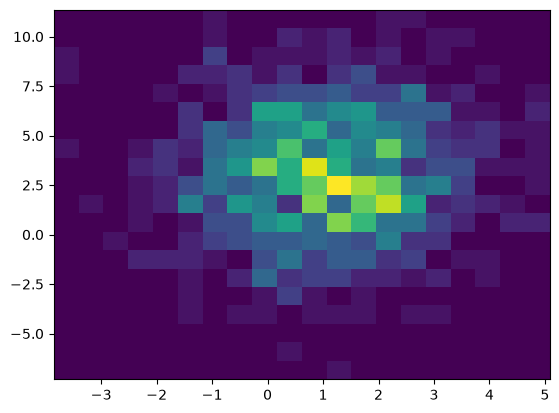

In [19]:
fig = plt.figure()
ax  = fig.add_subplot(111)

dist1 = GaussianDistribution(1.0, 2.0)
dist2 = GaussianDistribution(3.0, 8.0)
dist = CompositeDistribution((dist1, dist2))
data = dist.sampler(seed=1).sample(1000)
print(str(estimate(data, CompositeEstimator([GaussianEstimator()]*2))))

data = np.asarray(data)
ax.hist2d(data[:, 0], data[:, 1], bins=20);

In [20]:
dist1 = GaussianDistribution(1.0, 2.0)
dist2 = GeometricDistribution(0.2)
dist3 = CategoricalDistribution({'a': 0.1, 'b': 0.3, 'c': 0.6})

dist = CompositeDistribution((dist1, dist2, dist3))
data = dist.sampler(seed=1).sample(1000)
print('Estimate:')
print(str(estimate(data, CompositeEstimator((GaussianEstimator(), GeometricEstimator(), CategoricalEstimator())))))
print('\nSamples:')
print('\n'.join(map(str, data[:5])))

Estimate:
CompositeDistribution((GaussianDistribution(1.0361188291060461, 2.0085790142526143, name=None, keys=None),GeometricDistribution(0.2037905033625433, name=None, keys=None),CategoricalDistribution({'a': 0.102, 'b': 0.291, 'c': 0.607}, default_value=0.0, name=None, keys=None)))

Samples:
(np.float64(2.0812460074093333), np.int64(6), 'c')
(np.float64(-0.5899877730119981), np.int64(1), 'b')
(np.float64(0.8058051863743767), np.int64(3), 'a')
(np.float64(1.746912608168946), np.int64(1), 'c')
(np.float64(-0.18494064399906052), np.int64(4), 'c')


### Sequence

Use `SequenceDistribution` and `SequenceEstimator` when observing an independent and identically distributed sequence. Any given distribution for the sequence length distribution is independent of the observations. 

If `len_estimator` is not specified a length distribution is not estimated.


In [21]:
dist = CategoricalDistribution({'cat': 0.1, 'dog': 0.3, 'turtle': 0.6})
len_dist = CategoricalDistribution({1: 0.3, 2: 0.5, 3:0.2})
data = SequenceDistribution(dist, len_dist=len_dist).sampler(seed=1).sample(1000)

print('Estimate:')
print(str(estimate(data, SequenceEstimator(CategoricalEstimator(), len_estimator=CategoricalEstimator()))))
print('\nSamples:')
print('\n'.join([str(data[i]) for i in range(10)]))

Estimate:
SequenceDistribution(CategoricalDistribution({'cat': 0.09572192513368984, 'dog': 0.2914438502673797, 'turtle': 0.6128342245989304}, default_value=0.0, name=None, keys=None), len_dist=CategoricalDistribution({1: 0.317, 2: 0.496, 3: 0.187}, default_value=0.0, name=None, keys=None), len_normalized=False, name=None)

Samples:
['dog', 'turtle']
['turtle']
['dog', 'turtle']
['cat']
['turtle', 'dog']
['turtle', 'turtle', 'turtle']
['cat']
['turtle']
['turtle', 'cat']
['turtle', 'dog']


### Ignored

The `IgnoredDistribution` and `IgnoredEstimator` classes provide a way of either ignoring particular features or specifying distributions that are known in advance.


CompositeDistribution((GaussianDistribution(1.0361188291060461, 2.0085790142526143, name=None, keys=None),IgnoredDistribution(GaussianDistribution(3.0, 8.0, name=None, keys=None))))


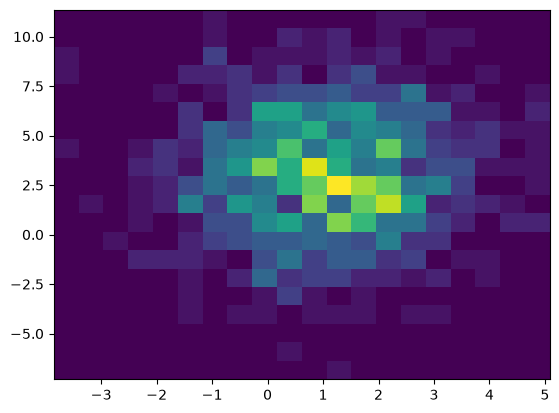

In [22]:
fig = plt.figure()
ax  = fig.add_subplot(111)

dist1 = GaussianDistribution(1.0, 2.0)
dist2 = GaussianDistribution(3.0, 8.0)
dist = CompositeDistribution((dist1, IgnoredDistribution(dist2)))
data = dist.sampler(seed=1).sample(1000)
print(str(estimate(data, CompositeEstimator([GaussianEstimator(), IgnoredEstimator(dist2)]))))

data = np.asarray(data)
ax.hist2d(data[:, 0], data[:, 1], bins=20);

### Optional

The `OptionalDistribution` allows for potentially missing data. The value `p` (the probability of being missing) must be specified to sample from the distribution.


In [23]:
dist1 = GaussianDistribution(1.0, 2.0)
dist2 = GaussianDistribution(3.0, 8.0)
dist = CompositeDistribution((dist1, OptionalDistribution(dist2, p=0.2, missing_value='bad')))
data = dist.sampler(seed=1).sample(1000)
print(str(estimate(data, CompositeEstimator([GaussianEstimator(), OptionalEstimator(GaussianEstimator(), est_prob=True, missing_value='bad')]))))

CompositeDistribution((GaussianDistribution(1.0361188291060461, 2.0085790142526143, name=None, keys=None),OptionalDistribution(GaussianDistribution(2.911977000725375, 7.81623892440505, name=None, keys=None), p=0.195, missing_value='bad', name=None)))


### Conditional

The `ConditionalDistribution` computes conditional probability density $P(Y|X)$ when the assumed data format is a tuple `(X, Y)`. `ConditionalDistributionEstimator` will estimate the joint proabability density function $P(Y|X)P(X)$ if the field `given_estimator` is specified. Similarly `ConditionalDistribution` will compute the joint proabability density function $P(Y|X)P(X)$ if `given_dist` is specified.


In [24]:
dist1 = GaussianDistribution(1.0, 2.0)
dist2 = GeometricDistribution(0.2)
dist3 = CategoricalDistribution({'a': 0.6, 'b': 0.4})
dist = ConditionalDistribution({'a': dist1, 'b': dist2}, given_dist=dist3)
data = dist.sampler(seed=1).sample(1000)

print('Estimate:')
est = ConditionalDistributionEstimator({'a': GaussianEstimator(), 'b': GeometricEstimator()}, given_estimator=CategoricalEstimator())
print(str(estimate(data, est)))
print('\nSamples:')
print('\n'.join(map(str, data[:5])))

Estimate:
ConditionalDistribution({'a': GaussianDistribution(1.015288252880407, 2.0892464476947707, name=None, keys=None), 'b': GeometricDistribution(0.21301775147928995, name=None, keys=None)}, default_dist=NullDistribution(name=None), given_dist=CategoricalDistribution({'a': 0.604, 'b': 0.396}, default_value=0.0, name=None, keys=None), name=None, keys=None)

Samples:
('b', 8)
('a', -0.5896057427239183)
('a', 2.7641808189968593)
('a', 0.9122118807402247)
('a', 0.36662169023795355)


### FiniteStochasticTransform - a noisy channel

`FiniteStochasticTransform` wraps a discrete source distribution with a row-stochastic kernel $K$: a source outcome $x$ is emitted as $y$ with probability $K_{x,y}$. It is the noisy-channel / measurement-error combinator - the observed symbol is a corrupted version of a latent one. Fitting recovers the source distribution seen through the known channel, and the enumerator walks outputs by their marginal probability $P(Y)$.


observed outputs y: [2, 3, 2, 2, 1, 0, 1, 0, 2, 3, 2, 0]
output marginal P(Y) : [0.38 0.3  0.17 0.15]
enumerator (desc P(Y)): [(0, 0.38), (1, 0.3), (2, 0.17), (3, 0.15)]


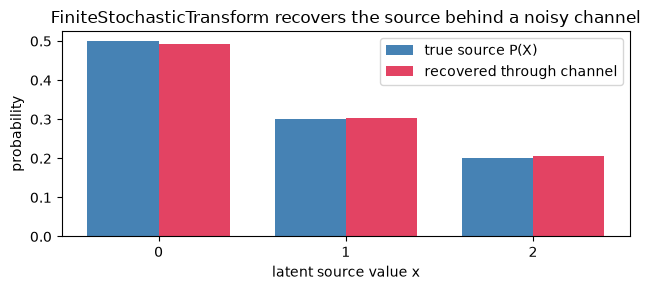

In [25]:
from mixle.stats import FiniteStochasticTransformDistribution
from mixle.inference.estimation import fit as _fit

K = np.array([[0.7, 0.2, 0.1, 0.0],      # P(y | x=0)
              [0.1, 0.6, 0.2, 0.1],      # P(y | x=1)
              [0.0, 0.1, 0.3, 0.6]])     # P(y | x=2)
src = IntegerCategoricalDistribution(0, [0.5, 0.3, 0.2])   # true latent source
fst = FiniteStochasticTransformDistribution(src, K)
obs = fst.sampler(seed=1).sample(4000)
print('observed outputs y:', obs[:12])

fitted = _fit(obs, fst.estimator(), max_its=30, out=None)
recovered = np.exp([fitted.dist.log_density(i) for i in range(3)])
print('output marginal P(Y) :', np.round(np.exp([fst.log_density(y) for y in range(4)]), 3))
print('enumerator (desc P(Y)):', [(y, round(float(np.exp(lp)), 3)) for y, lp in fst.enumerator()])

fig, ax = plt.subplots(figsize=(6.5, 3))
xs = np.arange(3); w = 0.38
ax.bar(xs - w/2, [0.5, 0.3, 0.2], w, color='steelblue', label='true source P(X)')
ax.bar(xs + w/2, recovered, w, color='crimson', alpha=0.8, label='recovered through channel')
ax.set_xticks(xs); ax.set_xlabel('latent source value x'); ax.set_ylabel('probability')
ax.set_title('FiniteStochasticTransform recovers the source behind a noisy channel'); ax.legend()
plt.tight_layout(); plt.show()

### More combinators: Select, Transform, Weighted, Record, DictRecord

Beyond Composite / Sequence / Optional / Ignored / Conditional, five more combinators round out the algebra:

- `Transform` - push a distribution through a deterministic map (`AffineTransform`, `LogTransform`, ...), with the density correction handled for you.
- `Select` - route each observation to one of several distributions via a `choice_function`.
- `Weighted` - attach per-observation weights to a distribution.
- `Record` / `DictRecord` - like `Composite`, but the fields are named (records / dicts) rather than positional tuples.


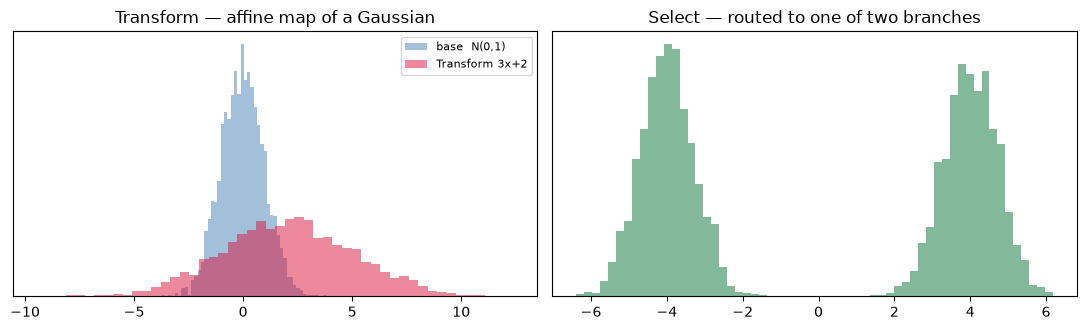

Weighted sample (value, weight): WeightedObservation(value=np.int64(6), weight=1.0)
Record sample (named fields)    : {'height': np.float64(1.981970372676524), 'count': np.int64(6)}


In [26]:
# Transform pushes a base distribution through a deterministic map (density-corrected).
base = GaussianDistribution(0.0, 1.0)
tx = TransformDistribution(base, AffineTransform(loc=2.0, scale=3.0))       # y = 3x + 2

# Select routes each observation to one branch via a choice_function.
# Without weights a Select only SCORES -- p(x | the branch choice_function picks) is a conditional
# factor with no law over which branch occurs, so it cannot generate. Declaring the branch law makes
# it a full distribution, which is what sampling below needs.
# Without weights a Select only SCORES -- p(x | the branch choice_function picks) is a conditional
# factor with no law over which branch occurs, so it cannot generate. Weights supply that law, and
# because the children have infinite support the routing cannot be checked exhaustively: assert it
# once with a stable contract id (draws are still checked as they are generated).
route = certify_select_routing(lambda x: 0 if x < 0 else 1, 'tutorial:two-sided-gaussian-split')
sel = SelectDistribution([GaussianDistribution(-4.0, 0.5), GaussianDistribution(4.0, 0.5)],
                         choice_function=route, weights=[0.5, 0.5])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
b = np.array(base.sampler(seed=0).sample(4000)); t = np.array(tx.sampler(seed=0).sample(4000))
ax[0].hist(b, bins=50, density=True, alpha=0.5, color='steelblue', label='base  N(0,1)')
ax[0].hist(t, bins=50, density=True, alpha=0.5, color='crimson', label='Transform 3x+2')
ax[0].set_title('Transform — affine map of a Gaussian'); ax[0].legend(fontsize=8); ax[0].set_yticks([])
sm = np.array(sel.sampler(seed=0).sample(4000))   # Gaussian branches emit scalars
ax[1].hist(sm, bins=60, color='seagreen', alpha=0.6)
ax[1].set_title('Select — routed to one of two branches'); ax[1].set_yticks([])
fig.tight_layout(); plt.show()

# Weighted attaches observation weights; Record / DictRecord name the fields of a composite.
wt  = WeightedDistribution(PoissonDistribution(4.0))
rec = RecordDistribution(['height', 'count'], [GaussianDistribution(0.0, 1.0), PoissonDistribution(4.0)])
print('Weighted sample (value, weight):', wt.sampler(seed=0).sample(1)[0])
print('Record sample (named fields)    :', rec.sampler(seed=0).sample(1)[0])